In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors
import geopandas as gpd
from shapely.geometry import Polygon, Point, MultiPoint
from geopy.distance import geodesic
import itertools

from unidecode import unidecode

In [3]:
# parameters
region_level = "nuts4"
industry_level = "nace3d"
year = 2017

**R1.1 -- co-located supplier patterns**

In [70]:
# matrix 1 -- average IO relatedness for coagglomerated and skill related industries

# SR and coagglomeration table
ii_reg = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_level}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)

# make a clean matrix
ii_mat = pd.pivot_table(ii_table,
        #values="io_norm3",
        values="io01",
        index="sr01",
        columns="colocation01",
        aggfunc="mean",
        margins=False)

#ff_mat_norm = ff_mat / ff_mat.sum().sum()
ii_mat.sort_values(by="sr01", ascending=False, inplace=True)

In [71]:
# matrix 3 -- supplier ties inside regions (co-location) between firms in SR and not SR industries
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf["nr_io_no_sr_ties"] = ddf["nr_io_ties"] - ddf["nr_io_sr_ties"]

# sum up ties, where distance > 0 (aka not the same region)
dist_0_row = ddf[ddf["dist_int"] == 0]
dist_0_row["colocation"] = 1
dist_above_0_rows = ddf[ddf["dist_int"] > 0]
summed_row = dist_above_0_rows.sum(numeric_only=True)
summed_row["colocation"] = 0

# combine
inreg = pd.concat([dist_0_row, pd.DataFrame([summed_row])], ignore_index=True)
inreg = inreg[["colocation", "nr_io_sr_ties", "nr_io_no_sr_ties"]]

# clean
inreg["colocation"] = inreg["colocation"].astype(int)
inreg.sort_values(by="colocation", ascending=True, inplace=True)
inreg.set_index("colocation", inplace=True)
inreg.columns = [1, 0]
inreg.columns.name = "sr01"
inreg = inreg.T.sort_values(by="sr01", ascending=False)
inreg_mat = (inreg / inreg.sum().sum())

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/3245892986.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dist_0_row["colocation"] = 1


In [82]:
# matrix 2 -- supplier ties inside regions (co-location) between firms in SR and not SR industries
selected_dist = 10
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf["nr_io_no_sr_ties"] = ddf["nr_io_ties"] - ddf["nr_io_sr_ties"]

ddf["colocation01"] = (ddf["dist_int"] <= selected_dist).astype(int)

# define a distance
table_d = ddf.groupby(["colocation01"]).agg(
    nr_io_sr_ties = pd.NamedAgg("nr_io_sr_ties", "sum"),
    nr_io_no_sr_ties = pd.NamedAgg("nr_io_no_sr_ties", "sum")
)

table_d.sort_values(by="colocation01", ascending=True, inplace=True)
#inreg.set_index("colocation01", inplace=True)
table_d.columns = [1, 0]
table_d.columns.name = "sr01"
table_d = table_d.T.sort_values(by="sr01", ascending=False)
table_d = (table_d / table_d.sum().sum())

In [83]:
def crosstab_visual(mat, fontsize, colormap, title_text=None, axis_labels=None, ax=None):
    if ax is None:
        ax = plt.gca()
    mh = sns.heatmap(
        mat,
        annot=True,
        annot_kws={"fontsize":(fontsize)},
        fmt=".2f",
        cbar=False,
        cmap=colormap,
        ax=ax
    )

    if axis_labels:
        ax.set_xlabel(axis_labels[0], fontsize=fontsize)
        ax.set_ylabel(axis_labels[1], fontsize=fontsize)
    
    if title_text:
        ax.set_title(title_text, fontsize=fontsize)
        

In [84]:
table_d

colocation01,0,1
sr01,,
1,0.372089,0.188029
0,0.302585,0.137297


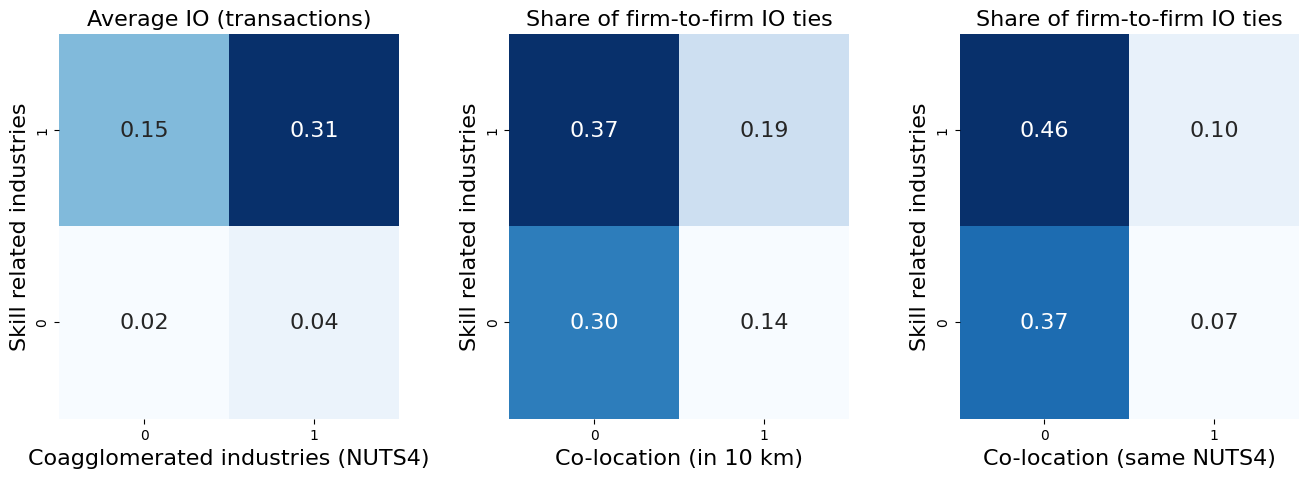

In [85]:
fig, ax = plt.subplots(1,3, figsize=(16,5))
plt.subplots_adjust(wspace=0.325)
fontsize = 16

crosstab_visual(
    ii_mat,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Average IO (transactions)",
    axis_labels=["Coagglomerated industries (NUTS4)", "Skill related industries"],
    ax=ax[0]
)

crosstab_visual(
    table_d,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Share of firm-to-firm IO ties",
    axis_labels=[f"Co-location (in {selected_dist} km)", "Skill related industries"],
    ax=ax[1]
)

crosstab_visual(
    inreg_mat,
    fontsize=fontsize,
    colormap="Blues",
    title_text="Share of firm-to-firm IO ties",
    axis_labels=["Co-location (same NUTS4)", "Skill related industries"],
    ax=ax[2]
) 

**R1.2 -- example searchh**

In [ ]:
# previous example industries
# 620 computer programming
# 631 data processing
# 310 manuf of furniture
# 211 manuf of pharma
industries = [211, 310, 620, 631]

In [4]:
# SR and coagglomeration table
ii_reg = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_level}_{year}.csv", sep=";")

def ind_ind_variables(df, colocation_variable):
    """function to speed up test with different coagglomeration measures"""
    df["sr01"] = (df["sr_norm"] > 0).astype(int)
    #df["colocation_median01"] = (df[colocation_variable] > df[colocation_variable].median()).astype(int)
    df["colocation01"] = (df[colocation_variable] > 0).astype(int)
    return df

ii_table = ind_ind_variables(ii_reg, colocation_variable="coagg_porter_rca01")
ii_table["io01"] = (ii_table["io_norm3"] > 0).astype(int)

In [20]:
# co-located + skill related + IO related | comp programming AND data processing
ii_table[(ii_table["ind1"]==620) & (ii_table["ind2"]==631)].loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
50035,620,631,0.014659,0.676393,0.804196,0.811361,1,1


In [21]:
# co-located + skill related + IO related | comp programming AND pharma
ii_table[(ii_table["ind1"]==620) & (ii_table["ind2"]==211)].loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
49904,620,211,0.003439,0.239513,0.164082,0.553976,1,1


In [35]:
ii_table[(ii_table["ind1"]==211) & (ii_table["coagg_porter_rca01"]<0) & (ii_table["sr_norm"]>0)]\
    .loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
15013,211,16,0.001785,-0.041137,0.352039,0.713143,1,1
15054,211,103,-0.006698,-0.138472,0.007848,-1.000000,1,0
15070,211,110,0.006262,-0.060768,0.082769,-1.000000,1,0
15124,211,221,-0.006742,-0.014587,0.188918,-1.000000,1,0
15229,211,329,-0.002407,-0.064456,0.774356,0.921070,1,1
15407,211,682,-0.001589,-0.066774,0.179286,-0.338913,1,0
15499,211,862,-0.001682,-0.074365,0.894157,-1.000000,1,0


In [36]:
ii_table[(ii_table["ind1"]==211) & (ii_table["coagg_porter_rca01"]<0) & (ii_table["io_norm3"]>0)]\
    .loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
15013,211,16,0.001785,-0.041137,0.352039,0.713143,1,1
15057,211,106,0.002303,-0.079230,-1.000000,0.599599,0,1
15229,211,329,-0.002407,-0.064456,0.774356,0.921070,1,1


In [22]:
# NOT co-located + NOT skill related + NOT IO related | furniture and pharma
ii_table[(ii_table["ind1"]==211) & (ii_table["ind2"]==310)].loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
15222,211,310,-0.000175,-0.107074,-1.0,-0.694417,0,0


In [23]:
# co-located + skill related + IO related
ii_table[(ii_table["ind1"]==631) & (ii_table["ind2"]==211)].loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
50228,631,211,0.000654,0.181237,-0.497943,-1.0,0,0


In [32]:
ii_table[(ii_table["ind1"]==310) & (ii_table["coagg_porter_rca01"]>0) & (ii_table["sr_norm"]>0)]\
    .loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
28684,310,22,0.011993,0.176634,0.163869,0.547248,1,1
28686,310,24,0.004528,0.071939,0.331628,-0.331356,1,0
28698,310,101,0.005168,0.114685,0.033034,-0.943003,1,0
28706,310,109,-0.000220,0.032776,0.137279,-1.000000,1,0
28710,310,132,0.007048,0.023398,0.673081,-1.000000,1,0
28712,310,139,-0.000463,0.051585,0.517923,0.900426,1,1
28717,310,152,0.005981,0.125541,0.227475,-0.196380,1,0
28718,310,161,0.007156,0.068524,0.688033,0.608873,1,1
28719,310,162,0.006400,0.141257,0.772111,0.798169,1,1
28721,310,172,0.000490,0.018001,0.006706,-0.644620,1,0


In [34]:
ii_table[(ii_table["ind1"]==310) & (ii_table["coagg_porter_rca01"]<0) & (ii_table["io_norm3"]>0)]\
    .loc[:,["ind1", "ind2", "egk_coagg", "coagg_porter_rca01", "sr_norm", "io_norm3", "sr01", "io01"]]

,ind1,ind2,egk_coagg,coagg_porter_rca01,sr_norm,io_norm3,sr01,io01
28683,310,21,0.002974,-0.040977,-0.076359,0.189789,0,1
28713,310,141,0.003598,-0.002414,0.494754,0.262220,1,1
28749,310,251,0.002800,-0.038108,0.295830,0.224989,1,1
28781,310,303,0.002893,-0.029184,-0.286172,0.495927,0,1
28801,310,411,0.000608,-0.032074,0.090648,0.583032,1,1
28817,310,464,-0.002031,-0.099971,0.331231,0.668295,1,1
28849,310,561,0.000865,-0.020840,-0.294570,0.053839,0,1
28852,310,581,-0.004181,-0.077299,-0.548751,0.229408,0,1
28868,310,649,-0.012816,-0.136504,-1.000000,0.009728,0,1
28875,310,681,-0.000513,-0.051162,-0.033553,0.429319,0,1


**R1.6 and R1.10 -- co-patenting and patent citations**

In [98]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, cbar_label, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(
            table,
            cbar=True,
            cmap=cmap,
            ax=ax
        )
        ax.figure.axes[-1].set_ylabel(cbar_label, size=fontsize-5)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)

        labels = table.index.tolist()  # Get row index labels
        tick_positions = [i + 0.5 for i in range(len(labels)) if i % 4 == 0]
        tick_labels = [labels[i] for i in range(len(labels)) if i % 4 == 0]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=90, fontsize=fontsize-10)

        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels, rotation=0, fontsize=fontsize-10)
        
        # Remove tick lines
        ax.tick_params(left=False, bottom=False)
        #ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.tick_params(left = False, bottom = False)

In [99]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [100]:
# citation based relatedness of 2-digit industries -- constructed in 06_revision.R
cr_table = pd.read_csv("../outputs/cr_norm_citation.csv", sep=";")
cr_table.rename(columns={"ind_i":"ind1", "ind_j":"ind2"}, inplace=True)
cr_table = cr_table[cr_table["ind1"] < cr_table["ind2"]]

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  table = pd.pivot_table(table,
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_4544/2790579632.py:11: FutureWarning: The provided callable <function max at 0x10c3037e0> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior p

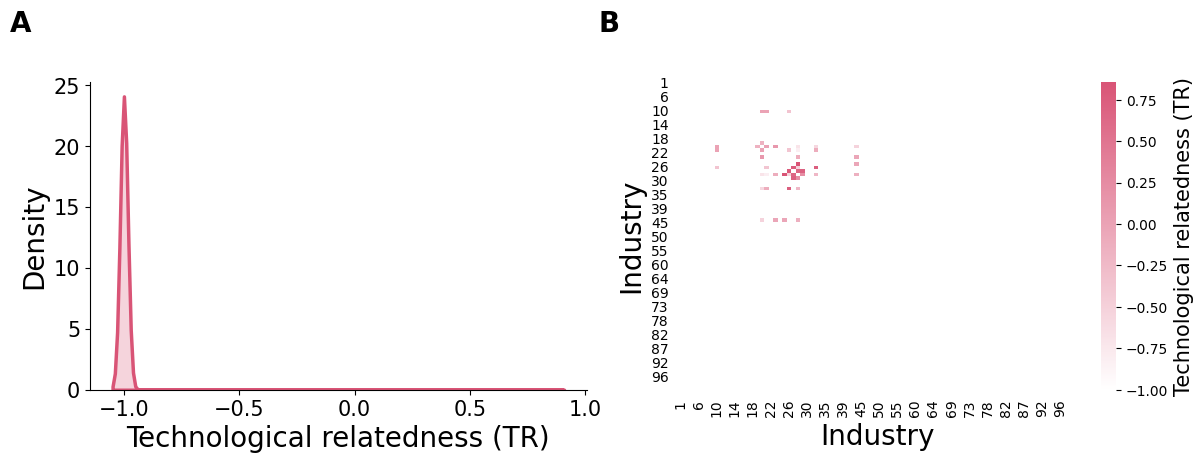

In [113]:
fig = plt.figure(figsize=(14, 4))
ax = [0]*2
gs = GridSpec(1,2, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[0,1])
fig.subplots_adjust(hspace=0.55, wspace=0.185) 

textsize = 20
key_var = "cr_norm"

# colormap
cvals  = [-1, 1]
colors = ["#FFFFFF","#D95476"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    cr_table,
    key_column=key_var,
    colorway=colors[1],
    xlabel_text="Technological relatedness (TR)",
    fontsize=textsize,
    ax=ax[0]
)

matrix_represantation(
    cr_table,
    key_columns=["ind1", "ind2", key_var],
    sort_matrix=False,
    heatmap=True,
    fontsize=textsize,
    title_text="",
    cmap=cmap,
    cbar_label="Technological relatedness (TR)",
    ax=ax[1]
)
ax[1].xaxis.set_tick_params(rotation=90, labelbottom=True)

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=textsize)

# plt.savefig(f"../figures/revision_technology_distribution.png", dpi=300, bbox_inches='tight', facecolor="white")

**interplots including citation data**

In [104]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../outputs/marginal_effects_for_interplots_with_citations.csv", sep=";")

In [105]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(-125, 75, 'H')

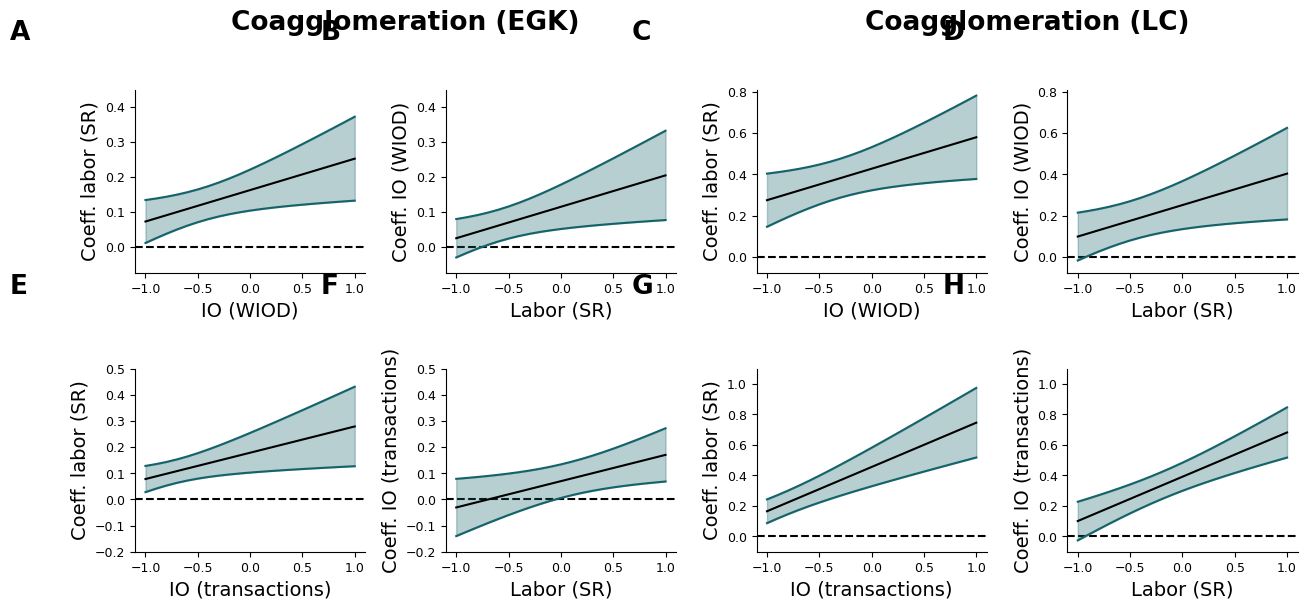

In [109]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/revision_interplots_with_tech.png", dpi=300, bbox_inches='tight', facecolor="white")

**R1.4 -- compare region sizes**

In [3]:
# shape IN
nuts3_gdf = gpd.read_file(f"../data/shape_files/nuts3_shape.geojson")
nuts4_gdf = gpd.read_file(f"../data/shape_files/nuts4_shape.geojson")

In [6]:
# raw numbers
print(nuts3_gdf["region_name"].nunique())
print(nuts4_gdf["region_name"].nunique())

20
197


In [53]:
# pop dense data to plot_df for comparison
pop_df = pd.read_csv("../data/nuts_population_density_HUN.csv", sep=";")

In [54]:
def aggregate_popdata(df, focal_year, region_id):
    """aggregate pop density data from Gergo"""
    df = df[df["year"] == focal_year]
    df = df.groupby(region_id).agg(
        area = pd.NamedAgg("area", "sum"),
        pop = pd.NamedAgg("pop", "sum")
    ).reset_index()
    return df

In [55]:
# NUTS3 descriptives
# shape IN
map_df = gpd.read_file(f"../data/shape_files/nuts3_shape.geojson")
map_df = map_df.to_crs("EPSG:4326")

# OC emp data by regions
reg_emp = pd.read_csv(f"../data/oc17_2024_febr2/regional_descriptive_final_sample_nuts3_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"

# print statistics
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id="nuts3")
print(np.mean(agg_pop_df["pop"]), " population")
print(np.mean(agg_pop_df["area"]), " area")

print(np.mean(reg_emp["total_firms"]), " firms")
print(np.std(reg_emp["total_firms"]), " std emp")
print(np.mean(reg_emp["total_emp"]), " emp")
print(np.std(reg_emp["total_emp"]), " std emp")

583175.2  population
4677.385  area
24619.55  firms
28756.39670312503  std emp
302408.75  emp
430003.24527727405  std emp


In [59]:
def calculate_polygon_diameter(polygon, sampling_density=100):
    """
    calculate the maximum geodesic distance (diameter) within a polygon.
    
    parameters:
        polygon (shapely.geometry.Polygon): The polygon for which to compute the diameter.
        sampling_density (int): Number of points to sample along the polygon boundary.

    returns:
        float: Maximum geodesic distance in kilometers.
    """
    # sample points along the boundary of the polygon
    boundary = polygon.exterior
    sampled_points = [
        boundary.interpolate(fraction, normalized=True)
        for fraction in [i / sampling_density for i in range(sampling_density + 1)]
    ]
    
    # convert sampled points to lat/lon tuples
    points = [(p.y, p.x) for p in sampled_points]  # (latitude, longitude) order for geodesic
    
    # compute pairwise distances
    max_distance = max(
        geodesic(pt1, pt2).kilometers for pt1, pt2 in itertools.combinations(points, 2)
    )
    
    return max_distance

# maximum geodesic distance for NUTS3
map_df["diameter_km"] = map_df.geometry.apply(calculate_polygon_diameter)
print(np.mean(map_df["diameter_km"]), " maximum geodesic distance")

106.96459324091668  maximum geodesic distance


In [60]:
# NUTS4 descriptives
# shape IN
map_df = gpd.read_file(f"../data/shape_files/nuts4_shape.geojson")
map_df = map_df.to_crs("EPSG:4326")

# OC emp data by regions
reg_emp = pd.read_csv(f"../data/oc17_2024_febr2/regional_descriptive_final_sample_nuts4_{year}.csv", sep=";")
reg_emp.columns.values[0] = "reg_code"

# print statistics
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id="nuts4")
print(np.mean(agg_pop_df["pop"]), " population")
print(np.mean(agg_pop_df["area"]), " area")

print(np.mean(reg_emp["total_firms"]), " firms")
print(np.std(reg_emp["total_firms"]), " std emp")
print(np.mean(reg_emp["total_emp"]), " emp")
print(np.std(reg_emp["total_emp"]), " std emp")

50611.43654822335  population
472.1957360406091  area
2499.4467005076144  firms
2572.588976908958  std emp
30701.23350253807  emp
42307.32374798777  std emp


In [61]:
# maximum geodesic distance for NUTS4
map_df["diameter_km"] = map_df.geometry.apply(calculate_polygon_diameter)
print(np.mean(map_df["diameter_km"]), " maximum geodesic distance")

33.30116323001948  maximum geodesic distance


In [29]:
# NUTS4 descriptives
agg_pop_df = aggregate_popdata(pop_df, focal_year=2017, region_id="nuts4")
print(np.mean(agg_pop_df["pop"]), " population")
print(np.mean(agg_pop_df["area"]), " area")

50611.43654822335  population
472.1957360406091  area


**R1.4 -- coagglomeration measured at different scale**

In [ ]:
# reg_df NUTS3
# reg_df NUTS4

# correlation of coagglomeration measures -- municipality?